<a href="https://colab.research.google.com/github/rubenesticesi/NLP/blob/main/MiniProyecto_Transformers_Gestion_Vulnerabilidades_EMCALI_Cyber2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

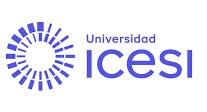

#Universidad ICESI

NLP - PROCESAMIENTO DE LENGUAJE NATURAL -
Profesor : Luis Ferro Diez
Cuaderno de Mini-Proyecto de clasificación de texto con Transformers - 3er semestre de 2026.
Presentado por : Edwin Perez -Rubén Darío Sabogal - Cristian Camilo Quebrada

# Mini‑Proyecto de clasificación de texto con Transformers
## Gestión de vulnerabilidades para ciberseguridad — EMCALI Cyber 2.0

**Caso propio:** clasificación automática de severidad a partir de descripciones CVE.

### Pregunta
**¿Puede un Transformer aprender señales lingüísticas de descripciones CVE para apoyar el triage inicial de vulnerabilidades y superar un baseline TF‑IDF?**

### Experimentos
1. TF‑IDF + Regresión Logística.
2. DistilBERT con texto original.
3. DistilBERT con texto sanitizado.
4. SecureBERT opcional.

### Métricas
Accuracy, Balanced Accuracy, Macro F1, Weighted F1, ROC‑AUC, matrices de confusión y análisis de errores.

### Fundamento
Usaremos transfer learning. El mecanismo de atención escalada es:

\[
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

**Uso responsable:** esta salida NLP no sustituye CVSS, EPSS, CISA KEV ni revisión humana.

# 1. Por qué este proyecto va más allá

Incluye EDA, auditoría de data leakage, sanitización de pistas explícitas, baseline clásico, ablación RAW vs CLEAN, análisis por clase, errores de alta confianza, self‑attention, demo y propuesta de integración con EMCALI Cyber 2.0.

# 2. Entorno

En Google Colab: **Entorno de ejecución → T4 GPU**.

Instalamos sólo dependencias NLP faltantes para no romper las versiones base de Colab.

In [1]:
%pip install -q "datasets" "transformers" "accelerate" "sentencepiece"

In [2]:
import re, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoConfig,  # Added AutoConfig import
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
print("CYBERSECURITY TRANSFORMER LAB - HEALTH CHECK")
print("="*70)
print("PyTorch:",torch.__version__)
print("CUDA:",torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))
print("Device:",DEVICE)

CYBERSECURITY TRANSFORMER LAB - HEALTH CHECK
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


# 3. Dataset

Usaremos `stasvinokur/cve-and-cwe-dataset-1999-2025`, basado en CVE/CWE/NVD.

Campos usados: `CVE-ID`, `DESCRIPTION`, `SEVERITY`, `CWE-ID`, `CVSS-V2`, `CVSS-V3`, `CVSS-V4`.

In [3]:
DATASET_NAME="stasvinokur/cve-and-cwe-dataset-1999-2025"
raw_ds=load_dataset(DATASET_NAME,split="train")
df=raw_ds.to_pandas()

print(raw_ds)
print("Columnas:",raw_ds.column_names)
display(df.head())

README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

CVE_CWE_2025.csv: reconstructing file:   0%|          |  0.00B /  103MB            

CVE_CWE_2025.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/280694 [00:00<?, ? examples/s]

Dataset({
    features: ['ID', 'CVE-ID', 'CVSS-V4', 'CVSS-V3', 'CVSS-V2', 'SEVERITY', 'DESCRIPTION', 'CWE-ID'],
    num_rows: 280694
})
Columnas: ['ID', 'CVE-ID', 'CVSS-V4', 'CVSS-V3', 'CVSS-V2', 'SEVERITY', 'DESCRIPTION', 'CWE-ID']


,ID,CVE-ID,CVSS-V4,CVSS-V3,CVSS-V2,SEVERITY,DESCRIPTION,CWE-ID
0,1,CVE-1999-0001,NaN,NaN,5.0,MEDIUM,ip_input.c in BSD-derived TCP/IP implementatio...,CWE-20
1,2,CVE-1999-0002,NaN,NaN,10.0,HIGH,Buffer overflow in NFS mountd gives root acces...,CWE-119
2,3,CVE-1999-0003,NaN,NaN,10.0,HIGH,Execute commands as root via buffer overflow i...,NVD-CWE-Other
3,4,CVE-1999-0004,NaN,NaN,5.0,MEDIUM,"MIME buffer overflow in email clients, e.g. So...",NVD-CWE-Other
4,5,CVE-1999-0005,NaN,NaN,10.0,HIGH,Arbitrary command execution via IMAP buffer ov...,NVD-CWE-Other


# 4. Auditoría inicial

In [4]:
VALID_LABELS=["LOW","MEDIUM","HIGH","CRITICAL"]

print("Forma:",df.shape)
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos").head(15))
display(df["SEVERITY"].value_counts(dropna=False).to_frame("n"))

work=df[["CVE-ID","DESCRIPTION","SEVERITY","CWE-ID","CVSS-V2","CVSS-V3","CVSS-V4"]].copy()
work["DESCRIPTION"]=work["DESCRIPTION"].fillna("").astype(str).str.strip()
work["SEVERITY"]=work["SEVERITY"].fillna("").astype(str).str.upper().str.strip()

work=work[
    work["SEVERITY"].isin(VALID_LABELS) &
    (work["DESCRIPTION"].str.len()>=30)
].copy()

print("Duplicados:",work.duplicated("DESCRIPTION").sum())
work=work.drop_duplicates("DESCRIPTION").reset_index(drop=True)
print("Filas útiles:",len(work))
display(work["SEVERITY"].value_counts().reindex(VALID_LABELS).to_frame("n"))

Forma: (280694, 8)


,nulos
CVSS-V4,273225
CVSS-V2,93666
CVSS-V3,76036
SEVERITY,2104
ID,0
CVE-ID,0
DESCRIPTION,0
CWE-ID,0


,n
SEVERITY,
MEDIUM,128681
HIGH,111472
CRITICAL,28552
LOW,9875
None,2104
NONE,10


Duplicados: 11976
Filas útiles: 266573


,n
SEVERITY,
LOW,9688
MEDIUM,124174
HIGH,104946
CRITICAL,27765


# 5. EDA — severidad y longitud

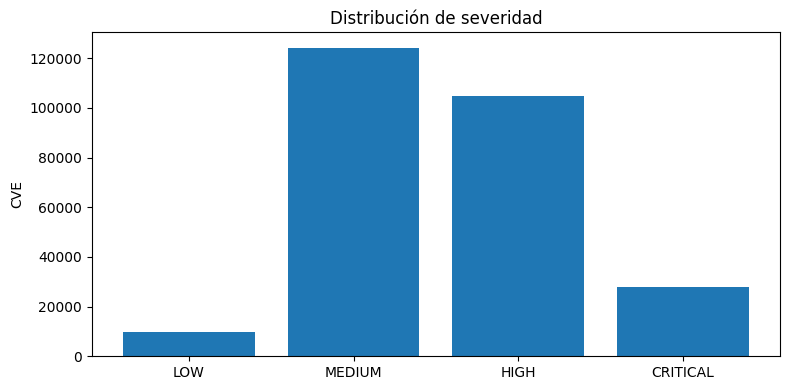

n_chars                                  n_words                \
           count    mean median     std min   max   count   mean median   
SEVERITY                                                                  
CRITICAL   27765  282.11  224.0  216.29  30  3875   27765  40.34   32.0   
HIGH      104946  307.45  243.0  261.16  30  3997  104946  44.42   36.0   
LOW         9688  308.93  249.0  210.95  30  3931    9688  45.58   37.0   
MEDIUM    124174  312.42  248.0  279.92  30  3995  124174  44.93   36.0   

                          
            std min  max  
SEVERITY                  
CRITICAL  31.04   4  637  
HIGH      34.59   4  637  
LOW       30.22   4  504  
MEDIUM    35.95   3  696

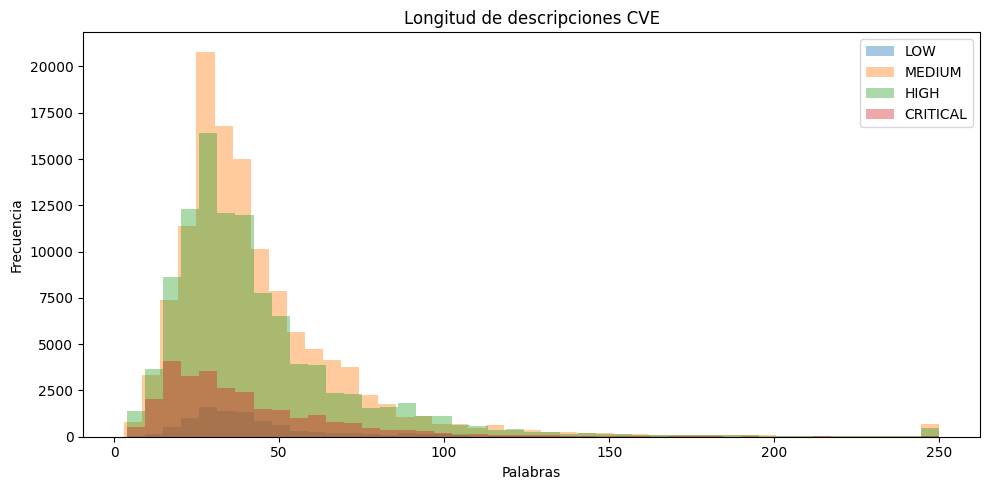

In [5]:
work["n_chars"]=work["DESCRIPTION"].str.len()
work["n_words"]=work["DESCRIPTION"].str.split().str.len()

counts=work["SEVERITY"].value_counts().reindex(VALID_LABELS)
plt.figure(figsize=(8,4))
plt.bar(counts.index,counts.values)
plt.title("Distribución de severidad")
plt.ylabel("CVE")
plt.tight_layout()
plt.show()

display(
    work.groupby("SEVERITY")[["n_chars","n_words"]]
    .agg(["count","mean","median","std","min","max"]).round(2)
)

plt.figure(figsize=(10,5))
for label in VALID_LABELS:
    vals=work.loc[work["SEVERITY"]==label,"n_words"].clip(upper=250)
    plt.hist(vals,bins=45,alpha=.4,label=label)
plt.title("Longitud de descripciones CVE")
plt.xlabel("Palabras"); plt.ylabel("Frecuencia"); plt.legend()
plt.tight_layout(); plt.show()

# 6. EDA — CWE más frecuentes

,n
CWE-ID,
NVD-CWE-Other,50781
CWE-79,34456
CWE-89,13779
CWE-119,11236
CWE-20,10357
CWE-200,8456
CWE-787,8359
CWE-352,7363
CWE-22,6665


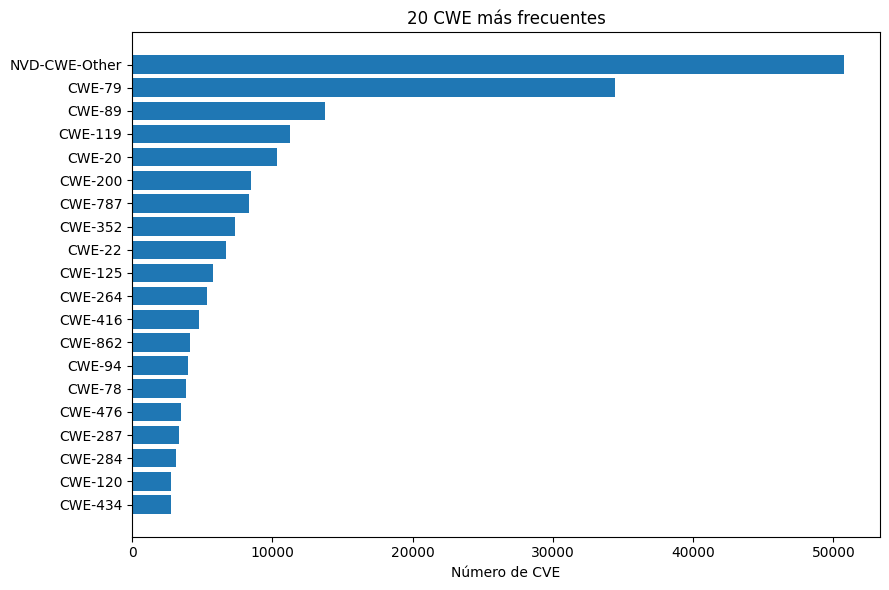

In [6]:
top_cwe=work["CWE-ID"].fillna("UNKNOWN").astype(str).value_counts().head(20)
display(top_cwe.to_frame("n"))

plt.figure(figsize=(9,6))
plt.barh(top_cwe.index[::-1],top_cwe.values[::-1])
plt.title("20 CWE más frecuentes")
plt.xlabel("Número de CVE")
plt.tight_layout(); plt.show()

# 7. Auditoría de fuga léxica

Una descripción puede contener pistas casi directas como `critical vulnerability` o `CVSS 9.8`.  
Mediremos esas señales y crearemos una versión sanitizada.

In [7]:
LEAK_PATTERNS={
    "mentions_low":r"\blow(?:\s+severity)?\b",
    "mentions_medium":r"\bmedium(?:\s+severity)?\b",
    "mentions_high":r"\bhigh(?:\s+severity)?\b",
    "mentions_critical":r"\bcritical(?:\s+severity)?\b",
    "mentions_cvss":r"\bcvss\b",
    "mentions_score_like":r"\b(?:[0-9]|10)(?:\.[0-9])\b"
}

rows=[]
for name,pattern in LEAK_PATTERNS.items():
    m=work["DESCRIPTION"].str.contains(pattern,case=False,regex=True,na=False)
    rows.append({"patron":name,"n":int(m.sum()),"porcentaje":float(m.mean()*100)})

leak_df=pd.DataFrame(rows)
display(leak_df.style.format({"porcentaje":"{:.2f}%"}))

,patron,n,porcentaje
0,mentions_low,4140,1.55%
1,mentions_medium,348,0.13%
2,mentions_high,4542,1.70%
3,mentions_critical,7039,2.64%
4,mentions_cvss,3922,1.47%
5,mentions_score_like,156185,58.59%


In [8]:
CVE_RE=re.compile(r"\bCVE-\d{4}-\d{4,}\b",re.I)
CWE_RE=re.compile(r"\bCWE-\d+\b",re.I)

def sanitize_text(text):
    text=str(text)
    text=CVE_RE.sub(" CVE_ID ",text)
    text=CWE_RE.sub(" CWE_ID ",text)
    text=re.sub(
        r"\b(?:low|medium|high|critical)(?:\s+severity)?\b",
        " SEVERITY_TOKEN ",text,flags=re.I
    )
    text=re.sub(
        r"\bCVSS(?:\s*(?:v?2(?:\.0)?|v?3(?:\.[01])?|v?4(?:\.0)?))?"
        r"(?:\s*(?:score|base score))?\s*[:=]?\s*(?:[0-9]|10)(?:\.[0-9])?\b",
        " CVSS_SCORE ",text,flags=re.I
    )
    return re.sub(r"\s+"," ",text).strip()

work["TEXT_RAW"]=work["DESCRIPTION"]
work["TEXT_CLEAN"]=work["DESCRIPTION"].apply(sanitize_text)

display(work[["SEVERITY","TEXT_RAW","TEXT_CLEAN"]].sample(6,random_state=SEED))

,SEVERITY,TEXT_RAW,TEXT_CLEAN
40257,MEDIUM,Cross-site scripting (XSS) vulnerability in se...,Cross-site scripting (XSS) vulnerability in se...
149947,MEDIUM,A vulnerability in the API of Cisco Meeting Se...,A vulnerability in the API of Cisco Meeting Se...
259720,HIGH,Improper Neutralization of Input During Web Pa...,Improper Neutralization of Input During Web Pa...
216238,HIGH,Tenda M3 V1.0.0.12(4856) was discovered to con...,Tenda M3 V1.0.0.12(4856) was discovered to con...
53442,MEDIUM,Unspecified vulnerability in bitcoind and Bitc...,Unspecified vulnerability in bitcoind and Bitc...
90923,MEDIUM,A information disclosure vulnerability in the ...,A information disclosure vulnerability in the ...


# 8. Muestra balanceada y split

- 70% Train
- 15% Validation
- 15% Test

`FAST_MODE=True` reduce el volumen para una ejecución corta.

In [9]:
FAST_MODE=False
MAX_PER_CLASS=500 if FAST_MODE else 1000

parts=[]
for label in VALID_LABELS:
    s=work[work["SEVERITY"]==label]
    parts.append(s.sample(n=min(MAX_PER_CLASS,len(s)),random_state=SEED))

sample_df=pd.concat(parts).sample(frac=1,random_state=SEED).reset_index(drop=True)

label2id={x:i for i,x in enumerate(VALID_LABELS)}
id2label={i:x for x,i in label2id.items()}
sample_df["label"]=sample_df["SEVERITY"].map(label2id)

train_df,temp_df=train_test_split(
    sample_df,test_size=.30,stratify=sample_df["label"],random_state=SEED
)
val_df,test_df=train_test_split(
    temp_df,test_size=.50,stratify=temp_df["label"],random_state=SEED
)

train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)

display(pd.DataFrame({
    "train":train_df["SEVERITY"].value_counts(),
    "validation":val_df["SEVERITY"].value_counts(),
    "test":test_df["SEVERITY"].value_counts()
}).reindex(VALID_LABELS))

,train,validation,test
SEVERITY,,,
LOW,700,150,150
MEDIUM,700,150,150
HIGH,700,150,150
CRITICAL,700,150,150


# 9. Baseline — TF‑IDF + Regresión Logística

In [10]:
tfidf=TfidfVectorizer(
    lowercase=True,strip_accents="unicode",
    ngram_range=(1,2),min_df=2,max_features=30000,sublinear_tf=True
)
X_train=tfidf.fit_transform(train_df["TEXT_CLEAN"])
X_test=tfidf.transform(test_df["TEXT_CLEAN"])

baseline=LogisticRegression(
    max_iter=2500,class_weight="balanced",random_state=SEED
)
baseline.fit(X_train,train_df["label"])
baseline_test_prob=baseline.predict_proba(X_test)

print("Features:",len(tfidf.get_feature_names_out()))

Features: 13537


In [11]:
def evaluate_predictions(name,y_true,probs):
    preds=np.asarray(probs).argmax(axis=1)
    p,r,f1,support=precision_recall_fscore_support(
        y_true,preds,labels=list(range(len(VALID_LABELS))),zero_division=0
    )
    y_bin=label_binarize(y_true,classes=list(range(len(VALID_LABELS))))
    try:
        auc=roc_auc_score(y_bin,probs,average="macro",multi_class="ovr")
    except Exception:
        auc=np.nan

    row={
        "modelo":name,
        "accuracy":accuracy_score(y_true,preds),
        "balanced_accuracy":balanced_accuracy_score(y_true,preds),
        "macro_f1":np.mean(f1),
        "weighted_f1":np.average(f1,weights=support),
        "roc_auc_macro_ovr":auc
    }
    pc=pd.DataFrame({
        "clase":VALID_LABELS,"precision":p,"recall":r,"f1":f1,"support":support
    })
    return row,pc,preds

y_test=test_df["label"].to_numpy()
baseline_row,baseline_pc,baseline_preds=evaluate_predictions(
    "TF-IDF + LogisticRegression",y_test,baseline_test_prob
)
display(pd.DataFrame([baseline_row]))
display(baseline_pc)

,modelo,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro_ovr
0,TF-IDF + LogisticRegression,0.62,0.62,0.617359,0.617359,0.831585


,clase,precision,recall,f1,support
0,LOW,0.726619,0.673333,0.698962,150
1,MEDIUM,0.584416,0.600000,0.592105,150
2,HIGH,0.546875,0.466667,0.503597,150
3,CRITICAL,0.620112,0.740000,0.674772,150


# 10. Features más influyentes del baseline

In [12]:
features=np.array(tfidf.get_feature_names_out())
for class_id,label in id2label.items():
    top=np.argsort(baseline.coef_[class_id])[-12:][::-1]
    print(label,"->",", ".join(features[top]))

LOW -> users to, local, users, allows local, local users, remote authenticated, information, authenticated users, authenticated, with, script or, which
MEDIUM -> xss, site, site scripting, cross, cross site, scripting, stored, xss via, missing, bug, id, xss in
HIGH -> privileges, execute, code, corruption, windows, impact, execute arbitrary, of privilege, arbitrary sql, to execute, dll, execution vulnerability
CRITICAL -> injection, code execution, code, execution, upload, remote code, unauthenticated, sql injection, authentication, allows attackers, command injection, sql


# 11. Tokenización Transformer

Usamos `distilbert-base-uncased`.  
`MAX_LENGTH` se deriva del percentil 95 del train y se limita a 256.

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (654 > 512). Running this sequence through the model will result in indexing errors


P50: 60
P90: 135
P95: 167
P99: 371
MAX_LENGTH: 167


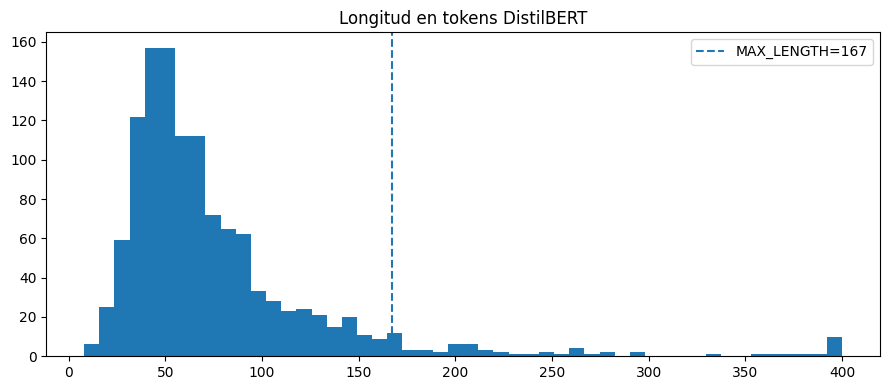

In [13]:
DISTILBERT_NAME="distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(DISTILBERT_NAME)

texts=train_df["TEXT_CLEAN"].sample(min(1200,len(train_df)),random_state=SEED).tolist()
lengths=[len(tokenizer.encode(t,add_special_tokens=True,truncation=False)) for t in texts]

p95=int(np.percentile(lengths,95))
MAX_LENGTH=int(np.clip(p95,64,256))

print("P50:",int(np.percentile(lengths,50)))
print("P90:",int(np.percentile(lengths,90)))
print("P95:",p95)
print("P99:",int(np.percentile(lengths,99)))
print("MAX_LENGTH:",MAX_LENGTH)

plt.figure(figsize=(9,4))
plt.hist(np.clip(lengths,0,400),bins=50)
plt.axvline(MAX_LENGTH,linestyle="--",label=f"MAX_LENGTH={MAX_LENGTH}")
plt.title("Longitud en tokens DistilBERT")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
class CVEDataset(Dataset):
    def __init__(self,frame,text_col,tokenizer,max_length):
        self.texts=frame[text_col].astype(str).tolist()
        self.labels=frame["label"].astype(int).tolist()
        self.tokenizer=tokenizer
        self.max_length=max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,i):
        enc=self.tokenizer(
            self.texts[i],padding="max_length",truncation=True,
            max_length=self.max_length,return_tensors="pt"
        )
        item={k:v.squeeze(0) for k,v in enc.items()}
        item["labels"]=torch.tensor(self.labels[i],dtype=torch.long)
        return item

# 12. Entrenamiento transparente

Loop PyTorch con class weights, AdamW, warmup, mixed precision, gradient clipping y selección del mejor estado por Macro F1 de validación.

In [20]:
import re, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoConfig,  # Added AutoConfig import
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
print("CYBERSECURITY TRANSFORMER LAB - HEALTH CHECK")
print("="*70)
print("PyTorch:",torch.__version__)
print("CUDA:",torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))
print("Device:",DEVICE)

@torch.no_grad()
def predict_transformer(model,loader):
    model.eval(); probs_all=[]; y_all=[]
    for batch in loader:
        y_all.append(batch["labels"].numpy())
        inputs={k:v.to(DEVICE) for k,v in batch.items() if k!="labels"}
        probs=torch.softmax(model(**inputs).logits,dim=1)
        probs_all.append(probs.cpu().numpy())
    return np.vstack(probs_all),np.concatenate(y_all)

def simple_metrics(y,probs):
    pred=probs.argmax(1)
    _,_,f1,support=precision_recall_fscore_support(
        y,pred,labels=list(range(len(VALID_LABELS))),zero_division=0
    )
    return {
        "accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),
        "macro_f1":float(np.mean(f1)),
        "weighted_f1":float(np.average(f1,weights=support))
    }

def train_transformer(model_name,text_col,run_name,epochs=2,batch_size=16,lr=2e-5):
    tok=AutoTokenizer.from_pretrained(model_name)
    tr_ds=CVEDataset(train_df,text_col,tok,MAX_LENGTH)
    va_ds=CVEDataset(val_df,text_col,tok,MAX_LENGTH)

    tr=DataLoader(tr_ds,batch_size=batch_size,shuffle=True,num_workers=0)
    va=DataLoader(va_ds,batch_size=batch_size*2,shuffle=False,num_workers=0)

    classes=np.array(sorted(train_df["label"].unique()))
    w=compute_class_weight("balanced",classes=classes,y=train_df["label"])
    w=torch.tensor(w,dtype=torch.float32,device=DEVICE)

    # Load configuration and ensure output_attentions is True
    config = AutoConfig.from_pretrained(model_name)
    config.output_attentions = True
    config.num_labels = len(VALID_LABELS) # Set num_labels in config
    config.id2label = id2label # Set id2label in config
    config.label2id = label2id # Set label2id in config

    model=AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config, # Pass the modified config
        # num_labels=len(VALID_LABELS), # Removed redundant num_labels
        # id2label=id2label,label2id=label2id # Removed redundant id2label and label2id
    ).to(DEVICE)

    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=.01)
    steps=len(tr)*epochs
    sch=get_linear_schedule_with_warmup(opt,max(1,int(.1*steps)),steps)
    loss_fn=nn.CrossEntropyLoss(weight=w)
    scaler=torch.amp.GradScaler("cuda",enabled=torch.cuda.is_available())

    history=[]; best_f1=-1; best_state=None
    t0=time.time()

    for epoch in range(1,epochs+1):
        model.train(); total_loss=0; n=0
        for batch in tr:
            labels=batch["labels"].to(DEVICE)
            inputs={k:v.to(DEVICE) for k,v in batch.items() if k!="labels"}
            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda",enabled=torch.cuda.is_available()):
                logits=model(**inputs).logits
                loss=loss_fn(logits,labels)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(opt); scaler.update(); sch.step()

            total_loss+=loss.item()*len(labels); n+=len(labels)

        val_probs,val_y=predict_transformer(model,va)
        m=simple_metrics(val_y,val_probs)
        history.append(
            {"epoch":epoch,"train_loss":total_loss/n,
            **{f"val_{k}":v for k,v in m.items()}}
        )

        print(f"{run_name} | epoch {epoch} | loss={total_loss/n:.4f} | val Macro F1={m['macro_f1']:.4f}")

        if m["macro_f1"]>best_f1:
            best_f1=m["macro_f1"]
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"{run_name}: {(time.time()-t0)/60:.2f} min | best val Macro F1={best_f1:.4f}")
    return model,tok,pd.DataFrame(history)

CYBERSECURITY TRANSFORMER LAB - HEALTH CHECK
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


# 13. DistilBERT RAW

In [21]:
EPOCHS=2
BATCH_SIZE=16 if torch.cuda.is_available() else 8

raw_model,raw_tok,hist_raw=train_transformer(
    DISTILBERT_NAME,"TEXT_RAW","DistilBERT_RAW",
    epochs=EPOCHS,batch_size=BATCH_SIZE,lr=2e-5
)
display(hist_raw)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT_RAW | epoch 1 | loss=1.2992 | val Macro F1=0.4726
DistilBERT_RAW | epoch 2 | loss=1.0719 | val Macro F1=0.5013
DistilBERT_RAW: 0.77 min | best val Macro F1=0.5013


,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1
0,1,1.299208,0.480000,0.480000,0.472592,0.472592
1,2,1.071889,0.506667,0.506667,0.501337,0.501337


# 14. DistilBERT CLEAN

In [22]:
clean_model,clean_tok,hist_clean=train_transformer(
    DISTILBERT_NAME,"TEXT_CLEAN","DistilBERT_CLEAN",
    epochs=EPOCHS,batch_size=BATCH_SIZE,lr=2e-5
)
display(hist_clean)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT_CLEAN | epoch 1 | loss=1.2846 | val Macro F1=0.4520
DistilBERT_CLEAN | epoch 2 | loss=1.0537 | val Macro F1=0.5177
DistilBERT_CLEAN: 0.75 min | best val Macro F1=0.5177


,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1
0,1,1.284641,0.473333,0.473333,0.451980,0.451980
1,2,1.053680,0.525000,0.525000,0.517745,0.517745


# 15. Curvas de validación

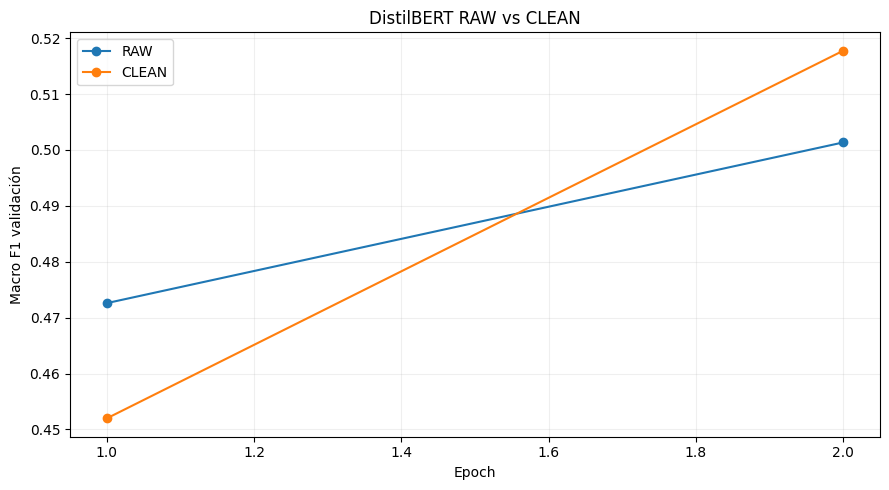

In [23]:
plt.figure(figsize=(9,5))
plt.plot(hist_raw["epoch"],hist_raw["val_macro_f1"],marker="o",label="RAW")
plt.plot(hist_clean["epoch"],hist_clean["val_macro_f1"],marker="o",label="CLEAN")
plt.xlabel("Epoch"); plt.ylabel("Macro F1 validación")
plt.title("DistilBERT RAW vs CLEAN")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

# 16. Evaluación final en Test

In [24]:
def make_loader(frame,text_col,tok,batch_size=32):
    return DataLoader(
        CVEDataset(frame,text_col,tok,MAX_LENGTH),
        batch_size=batch_size,shuffle=False,num_workers=0
    )

raw_probs,y1=predict_transformer(raw_model,make_loader(test_df,"TEXT_RAW",raw_tok))
clean_probs,y2=predict_transformer(clean_model,make_loader(test_df,"TEXT_CLEAN",clean_tok))
assert np.array_equal(y1,y2)

raw_row,raw_pc,raw_preds=evaluate_predictions("DistilBERT RAW",y1,raw_probs)
clean_row,clean_pc,clean_preds=evaluate_predictions("DistilBERT CLEAN",y2,clean_probs)

results_df=pd.DataFrame([baseline_row,raw_row,clean_row]).sort_values("macro_f1",ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "accuracy":"{:.4f}","balanced_accuracy":"{:.4f}",
    "macro_f1":"{:.4f}","weighted_f1":"{:.4f}",
    "roc_auc_macro_ovr":"{:.4f}"
}))

,modelo,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro_ovr
0,TF-IDF + LogisticRegression,0.6200,0.6200,0.6174,0.6174,0.8316
1,DistilBERT RAW,0.5333,0.5333,0.5329,0.5329,0.7730
2,DistilBERT CLEAN,0.5217,0.5217,0.5203,0.5203,0.7728


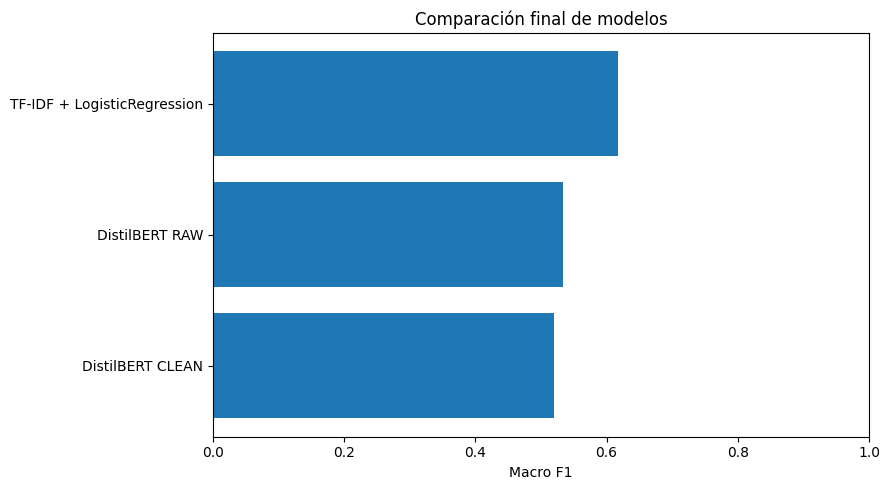

In [25]:
plot_df=results_df.sort_values("macro_f1")
plt.figure(figsize=(9,5))
plt.barh(plot_df["modelo"],plot_df["macro_f1"])
plt.xlabel("Macro F1"); plt.xlim(0,1)
plt.title("Comparación final de modelos")
plt.tight_layout(); plt.show()

# 17. Matrices de confusión

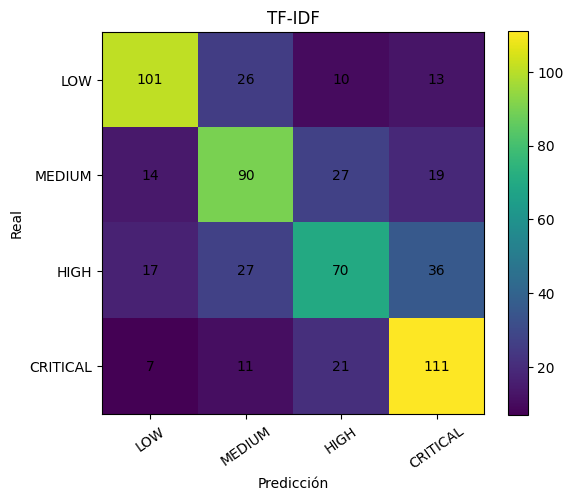

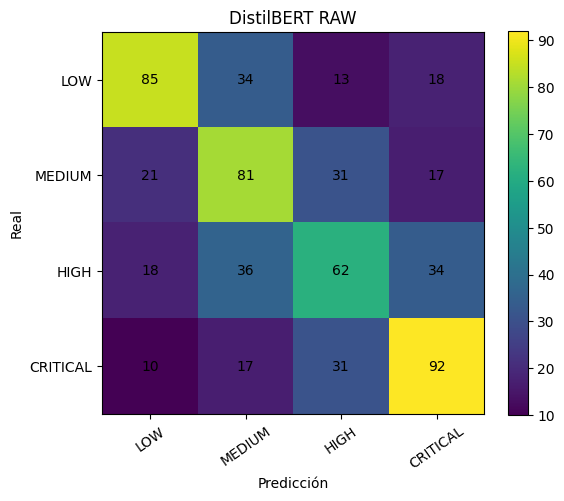

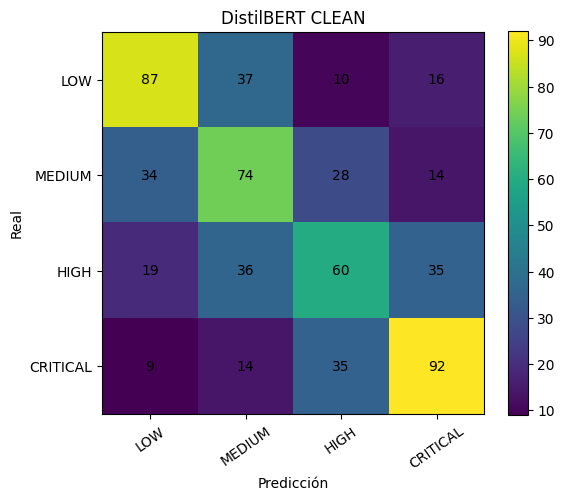

In [26]:
for name,preds in {
    "TF-IDF":baseline_preds,
    "DistilBERT RAW":raw_preds,
    "DistilBERT CLEAN":clean_preds
}.items():
    cm=confusion_matrix(y_test,preds,labels=list(range(4)))
    plt.figure(figsize=(6,5))
    plt.imshow(cm); plt.colorbar()
    plt.title(name); plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.xticks(range(4),VALID_LABELS,rotation=35)
    plt.yticks(range(4),VALID_LABELS)
    for i in range(4):
        for j in range(4):
            plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.tight_layout(); plt.show()

# 18. Reporte por clase

In [27]:
print(classification_report(
    y_test,clean_preds,target_names=VALID_LABELS,digits=4,zero_division=0
))

              precision    recall  f1-score   support

         LOW     0.5839    0.5800    0.5819       150
      MEDIUM     0.4596    0.4933    0.4759       150
        HIGH     0.4511    0.4000    0.4240       150
    CRITICAL     0.5860    0.6133    0.5993       150

    accuracy                         0.5217       600
   macro avg     0.5202    0.5217    0.5203       600
weighted avg     0.5202    0.5217    0.5203       600



# 19. Ablación RAW vs CLEAN

In [28]:
delta=raw_row["macro_f1"]-clean_row["macro_f1"]
print("RAW Macro F1  :",round(raw_row["macro_f1"],4))
print("CLEAN Macro F1:",round(clean_row["macro_f1"],4))
print("Δ RAW-CLEAN   :",round(delta,4))

if delta>.05:
    print("Caída apreciable: probable dependencia de pistas explícitas.")
elif delta>.01:
    print("Caída moderada: las pistas ayudan, pero no explican todo.")
else:
    print("Diferencia pequeña: el modelo parece usar señales más amplias.")

RAW Macro F1  : 0.5329
CLEAN Macro F1: 0.5203
Δ RAW-CLEAN   : 0.0126
Caída moderada: las pistas ayudan, pero no explican todo.


# 20. Errores de alta confianza

In [29]:
errors=test_df[["CVE-ID","CWE-ID","SEVERITY","TEXT_RAW","TEXT_CLEAN","label"]].copy()
errors["pred_id"]=clean_preds
errors["pred"]=[id2label[i] for i in clean_preds]
errors["confidence"]=clean_probs.max(1)
errors["correct"]=errors["label"]==errors["pred_id"]

mistakes=errors[~errors["correct"]].sort_values("confidence",ascending=False)

print("Errores:",len(mistakes))
print("Errores con confianza >= .80:",int((mistakes["confidence"]>=.80).sum()))
display(mistakes[["CVE-ID","CWE-ID","SEVERITY","pred","confidence","TEXT_RAW"]].head(20))

Errores: 287
Errores con confianza >= .80: 0


,CVE-ID,CWE-ID,SEVERITY,pred,confidence,TEXT_RAW
321,CVE-2009-0719,NVD-CWE-Other,MEDIUM,LOW,0.793487,Unspecified vulnerability in useradd in HP HP-...
523,CVE-2012-4593,CWE-264,MEDIUM,LOW,0.779380,McAfee Application Control and Change Control ...
509,CVE-2015-0394,NVD-CWE-Other,MEDIUM,LOW,0.777470,Unspecified vulnerability in the PeopleSoft En...
174,CVE-2016-6435,CWE-200,MEDIUM,LOW,0.776402,The web console in Cisco Firepower Management ...
318,CVE-2005-1339,NVD-CWE-Other,HIGH,LOW,0.771912,lukemftpd in Mac OS X 10.3.9 allows remote aut...
47,CVE-2002-1875,NVD-CWE-Other,MEDIUM,LOW,0.767681,"Entercept Agent 2.5 agent for Windows, release..."
169,CVE-2018-15720,CWE-798,CRITICAL,LOW,0.761316,Logitech Harmony Hub before version 4.15.206 c...
431,CVE-2016-10709,CWE-78,HIGH,LOW,0.751461,pfSense before 2.3 allows remote authenticated...
555,CVE-2016-1719,CWE-119,HIGH,LOW,0.751398,"The IOHIDFamily API in Apple iOS before 9.2.1,..."
576,CVE-1999-0210,NVD-CWE-Other,HIGH,LOW,0.749148,Automount daemon automountd allows local or re...


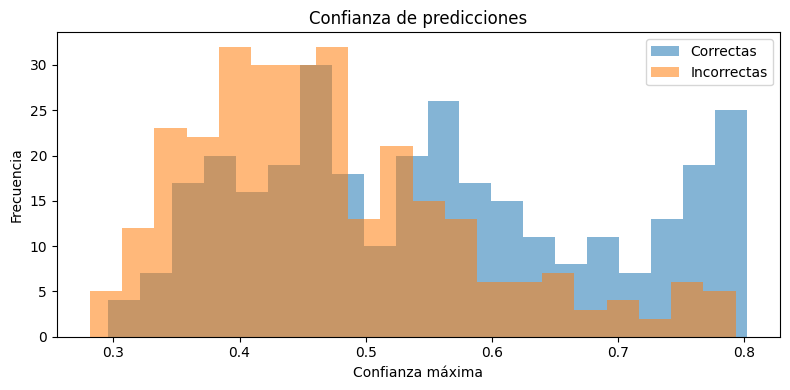

In [30]:
plt.figure(figsize=(8,4))
plt.hist(errors.loc[errors["correct"],"confidence"],bins=20,alpha=.55,label="Correctas")
plt.hist(errors.loc[~errors["correct"],"confidence"],bins=20,alpha=.55,label="Incorrectas")
plt.xlabel("Confianza máxima"); plt.ylabel("Frecuencia")
plt.title("Confianza de predicciones")
plt.legend(); plt.tight_layout(); plt.show()

# 21. Self‑attention

Observamos tokens con mayor atención desde `[CLS]` en la última capa.

**Advertencia:** atención no equivale automáticamente a explicación causal.

Predicción: CRITICAL | confianza: 0.633


,token,attention
2,vulnerability,0.049135
1,a,0.048093
3,has,0.036620
30,vulnerability,0.028250
72,to,0.028037
57,exploit,0.026435
50,attack,0.025366
38,component,0.024699
70,is,0.024651
4,been,0.023690


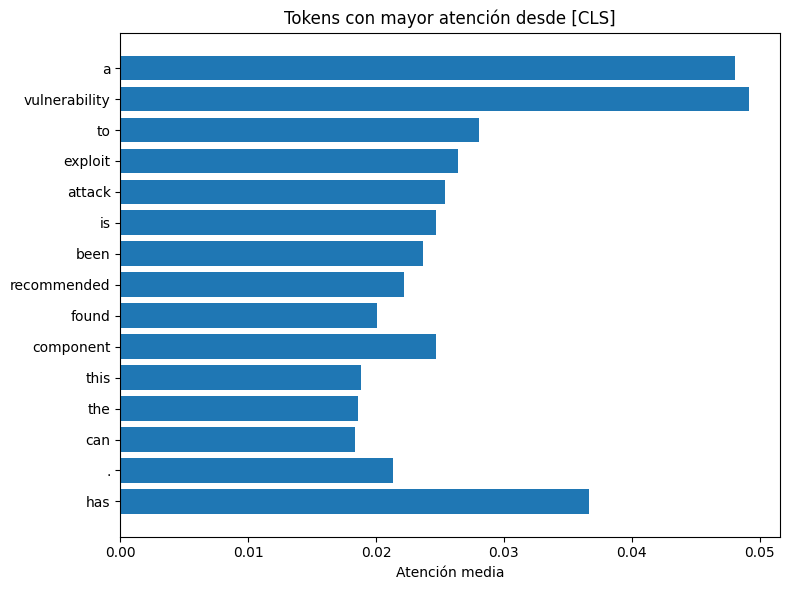

In [31]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def attention_view(text,model=clean_model,tokenizer=clean_tok,top_k=20):
    enc=tokenizer(text,return_tensors="pt",truncation=True,max_length=MAX_LENGTH)
    enc={k:v.to(DEVICE) for k,v in enc.items()}
    out=model(**enc,output_attentions=True,return_dict=True)
    probs=torch.softmax(out.logits,dim=1)[0]
    pred=int(probs.argmax())
    # Fix: Use combined indexing for robust attention extraction
    att=out.attentions[-1][0,:,0,:].mean(0).cpu().numpy()
    tokens=tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    d=pd.DataFrame({"token":tokens,"attention":att})
    d=d[~d["token"].isin(["[CLS]","[SEP]","[PAD]"])]

    # Check if 'd' is empty before sorting and taking head
    if not d.empty:
        d=d.sort_values("attention",ascending=False)
    else:
        print("No relevant tokens found for attention visualization.")
        return pd.DataFrame(columns=["token", "attention"])

    print("Predicción:",id2label[pred],"| confianza:",round(float(probs[pred]),3))
    return d.head(top_k)

attn=attention_view(test_df.iloc[0]["TEXT_CLEAN"])
display(attn)

p=attn.sort_values("attention")
plt.figure(figsize=(8,6))
plt.barh(p["token"],p["attention"])
plt.title("Tokens con mayor atención desde [CLS]")
plt.xlabel("Atención media")
plt.tight_layout(); plt.show()

# 22. Demo de triage

In [32]:
@torch.no_grad()
def predict_vulnerability(text):
    clean=sanitize_text(text)
    enc=clean_tok(
        clean,return_tensors="pt",padding=True,
        truncation=True,max_length=MAX_LENGTH
    )
    enc={k:v.to(DEVICE) for k,v in enc.items()}
    probs=torch.softmax(clean_model(**enc).logits,dim=1)[0].cpu().numpy()
    pred=int(np.argmax(probs))

    print("Predicción NLP:",id2label[pred])
    print("Confianza:",round(float(probs[pred]),3))
    print("⚠️ No reemplaza CVSS, EPSS, KEV ni revisión humana.")

    return pd.DataFrame({
        "severity":VALID_LABELS,
        "probability":probs
    }).sort_values("probability",ascending=False)

demo=(
    "A remote unauthenticated attacker can send a specially crafted request "
    "to a network-facing service and execute arbitrary code with system privileges. "
    "No user interaction is required."
)

display(predict_vulnerability(demo))

Predicción NLP: CRITICAL
Confianza: 0.519
⚠️ No reemplaza CVSS, EPSS, KEV ni revisión humana.


,severity,probability
3,CRITICAL,0.519287
2,HIGH,0.333913
1,MEDIUM,0.096607
0,LOW,0.050193


# 23. Experimento opcional — SecureBERT

Activar `RUN_SECUREBERT=True` para comparar un modelo especializado en ciberseguridad.

In [33]:
RUN_SECUREBERT=False
SECUREBERT_NAME="ehsanaghaei/SecureBERT"

if RUN_SECUREBERT:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    secure_model,secure_tok,hist_secure=train_transformer(
        SECUREBERT_NAME,"TEXT_CLEAN","SecureBERT_CLEAN",
        epochs=2,batch_size=8 if torch.cuda.is_available() else 4,lr=1e-5
    )
    secure_probs,secure_y=predict_transformer(
        secure_model,make_loader(test_df,"TEXT_CLEAN",secure_tok,16)
    )
    secure_row,secure_pc,secure_preds=evaluate_predictions(
        "SecureBERT CLEAN",secure_y,secure_probs
    )
    results_df=pd.concat([results_df,pd.DataFrame([secure_row])],ignore_index=True)
    results_df=results_df.sort_values("macro_f1",ascending=False).reset_index(drop=True)
    display(results_df)
else:
    print("SecureBERT omitido. Cambie RUN_SECUREBERT=True para ejecutarlo.")

SecureBERT omitido. Cambie RUN_SECUREBERT=True para ejecutarlo.


# 24. Narrativa automática

In [34]:
best=results_df.sort_values("macro_f1",ascending=False).iloc[0]
base=results_df[results_df["modelo"]=="TF-IDF + LogisticRegression"].iloc[0]
clean=results_df[results_df["modelo"]=="DistilBERT CLEAN"].iloc[0]
diff=clean["macro_f1"]-base["macro_f1"]

print("="*80)
print("HALLAZGOS")
print("="*80)
print(f"1. Mejor Macro F1: {best['modelo']} = {best['macro_f1']:.4f}")
print(f"2. DistilBERT CLEAN vs TF-IDF: {diff:+.4f} Macro F1.")
print(f"3. Ablación RAW-CLEAN: {delta:+.4f}.")
worst=clean_pc.sort_values("f1").iloc[0]
print(f"4. Clase más difícil: {worst['clase']} | F1={worst['f1']:.4f}.")
print("5. Revisar manualmente los errores de alta confianza.")

HALLAZGOS
1. Mejor Macro F1: TF-IDF + LogisticRegression = 0.6174
2. DistilBERT CLEAN vs TF-IDF: -0.0971 Macro F1.
3. Ablación RAW-CLEAN: +0.0126.
4. Clase más difícil: HIGH | F1=0.4240.
5. Revisar manualmente los errores de alta confianza.


# 25. Integración con EMCALI Cyber 2.0

```text
NVD / Tenable / Qualys / OpenVAS
              │
              ▼
      Descripción del hallazgo
              │
              ▼
        Transformer NLP
              │
      severidad + confianza
              │
              ▼
 Motor de priorización real
 CVSS + EPSS + KEV + activo
              │
              ▼
        RAG / recomendación
```

El Transformer es una señal complementaria, no el motor definitivo de riesgo.

# 26. Limitaciones y futuras mejoras

### Limitaciones
- mezcla años y versiones de CVSS;
- la severidad no depende sólo del texto;
- balancear clases altera la distribución natural;
- DistilBERT es generalista;
- self‑attention no es explicación causal;
- no se incorporan EPSS, KEV ni criticidad del activo.

### Próxima versión
- split temporal;
- SecureBERT 2.0;
- clasificación multi‑tarea severidad + CWE;
- CVE → ATT&CK;
- calibration / Temperature Scaling;
- conformal prediction;
- Integrated Gradients;
- FAISS / Chroma / pgvector;
- RAG;
- cuantización local;
- monitorización de drift.

# 27. Exportación

In [35]:
ARTIFACT_DIR=Path("artifacts_transformers_cyber")
ARTIFACT_DIR.mkdir(exist_ok=True)

results_df.to_csv(ARTIFACT_DIR/"model_comparison.csv",index=False)
mistakes.to_csv(ARTIFACT_DIR/"high_confidence_errors.csv",index=False)
leak_df.to_csv(ARTIFACT_DIR/"lexical_leakage_audit.csv",index=False)

config={
    "seed":SEED,
    "dataset":DATASET_NAME,
    "classes":VALID_LABELS,
    "max_per_class":MAX_PER_CLASS,
    "max_length":MAX_LENGTH,
    "model":DISTILBERT_NAME,
    "epochs":EPOCHS,
    "batch_size":BATCH_SIZE
}

with open(ARTIFACT_DIR/"config.json","w",encoding="utf-8") as f:
    json.dump(config,f,indent=2,ensure_ascii=False)

print("Artefactos:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print("-",p)

Artefactos:
- artifacts_transformers_cyber/config.json
- artifacts_transformers_cyber/high_confidence_errors.csv
- artifacts_transformers_cyber/lexical_leakage_audit.csv
- artifacts_transformers_cyber/model_comparison.csv


# 28. Guion de exposición

> “Clasifiqué severidad de vulnerabilidades usando descripciones CVE. Primero hice EDA y una auditoría de fuga léxica, porque algunas descripciones pueden decir directamente critical o contener scores CVSS.”

> “Construí un baseline TF‑IDF y dos DistilBERT: RAW y CLEAN. La ablación permite saber si el modelo aprende contexto o usa pistas explícitas.”

> “Evalué Macro F1, Balanced Accuracy, ROC‑AUC, matrices de confusión, errores de alta confianza y self‑attention.”

> “Para EMCALI Cyber 2.0, el Transformer se usaría como señal de triage y enriquecimiento; no reemplaza CVSS, EPSS, KEV ni revisión humana.”

# 29. Referencias

- Vaswani et al. (2017), *Attention Is All You Need*.
- Devlin et al., *BERT*.
- Sanh et al., *DistilBERT*.
- Aghaei et al., *SecureBERT*.
- NIST / NVD.
- MITRE / CWE.
- Hugging Face Transformers.
- Dataset: `stasvinokur/cve-and-cwe-dataset-1999-2025`.